### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [4]:
from wordcloud import WordCloud

In [53]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

### Step 2: Constant

In [6]:
FILE_PATH = './data/Restaurant_Reviews.tsv'
MAX_FEATURES = 1500

### Step 3: Load Data

In [7]:
df = pd.read_csv(FILE_PATH, delimiter='\t')

In [8]:
df.shape

(1000, 2)

In [9]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


### Step 4: Exploaring Data

#### Basic Info

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Liked,1000.0,0.5,0.50025,0.0,0.0,0.5,1.0,1.0


In [11]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum() / len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [12]:
feature_info

,null,null(%),unique,type
Review,0,0.0,996,object
Liked,0,0.0,2,int64


#### Target Distribution

In [13]:
temp = df['Liked'].value_counts()

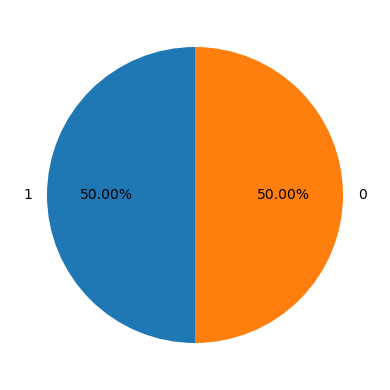

In [14]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    startangle=90
)
plt.tight_layout()

### Step 5: Preparing Data

#### Clean Text

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

In [17]:
df['Value'] = df['Review'].map(clean_text)

In [18]:
df.head()

,Review,Liked,Value
0,Wow... Loved this place.,1,wow loved place
1,Crust is not good.,0,crust good
2,Not tasty and the texture was just nasty.,0,tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great price


#### World Cloud

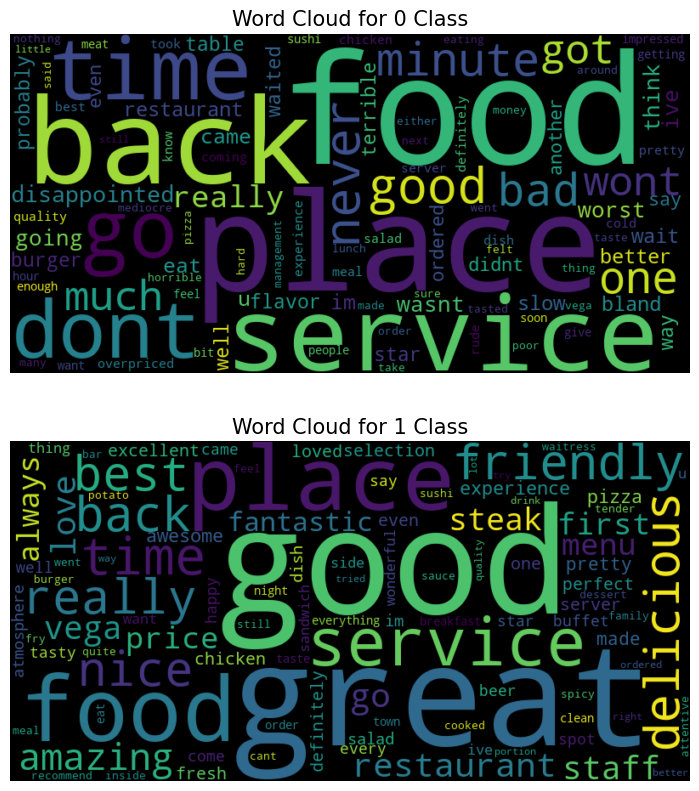

In [19]:
plt.figure(figsize=(10, 15))
for i in range(2):
    temp = df[df['Liked']==i]
    corpus = " ".join(temp['Value'])
    wc = WordCloud(
        max_words=100, 
        width=800, 
        height=400,
        collocations=False
    ).generate(corpus)
    plt.subplot(3, 1, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {i} Class", fontsize=15)

#### Split Data

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Value'],
    df['Liked'],
    test_size=0.25,
    random_state=42
)

#### Bag of Words

In [56]:
cv = CountVectorizer(max_features=MAX_FEATURES)

In [57]:
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

### Step 6: Model Development

#### Train Model

In [58]:
model = RandomForestClassifier(
    n_estimators=501,
    criterion='entropy'
)

In [59]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring='accuracy',
    cv=5,
    error_score='raise'
)

In [60]:
print('training accurary scores:', [float(round(score, 3)) for score in scores])
print('training accurary score:', round(scores.mean(), 3))

training accurary scores: [0.8, 0.767, 0.76, 0.713, 0.733]
training accurary score: 0.755


In [61]:
model.fit(X_train, y_train)

,n_estimators,501
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Predict Model

In [64]:
y_pred = model.predict(X_test)

In [65]:
print('testing accuracy score:', round(metrics.accuracy_score(y_test, y_pred), 3))

testing accuracy score: 0.724


In [66]:
cm = metrics.confusion_matrix(y_test, y_pred)

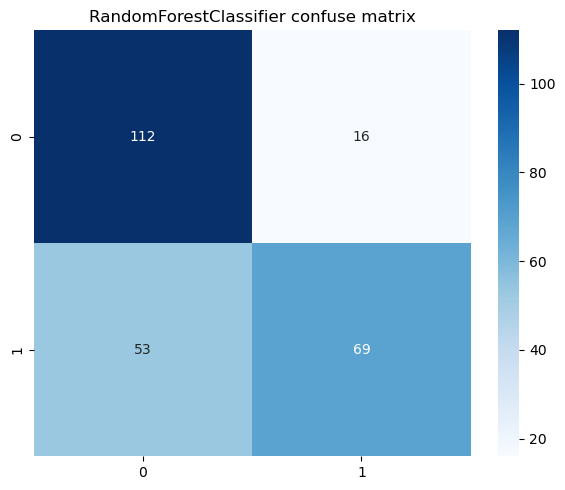

In [69]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues
)
plt.title(f'{model.__class__.__name__} confuse matrix')
plt.tight_layout()